# Smooth Statistics Labels

`smooth_labels()` has been added for `geom_smooth()` layer. It can compute and display additional smooth statistics that describe the fitted model quality and the fitted equation. These values are exposed as smooth label variables (such as `..r2..` and `..adjr2..`) and are available only within the `smooth_labels()` layer annotation.

`smooth_labels()` is an annotation helper designed specifically for smooth layers. It extends `layer_labels()`, so the familiar label-building API (`line()`, `format()`, `size()`, etc.) works the same way, while adding support for smooth-stat variables and the equation marker.

Supported variables and markers:

* `..r2..` — **R² (coefficient of determination)**. A goodness-of-fit measure showing what fraction of the variance in the response is explained by the fitted model. Values are typically between 0 and 1 (higher means the model explains more of the observed variation).
* `..adjr2..` — **adjusted R²**. A variant of R² that accounts for model complexity: it penalizes adding extra terms/parameters and is therefore more suitable for comparing models with different numbers of predictors (e.g., different polynomial degrees). Adjusted R² can be lower than R² and may even be negative for a very poor fit.
* `~eq` — **fitted equation**. Inserts the model equation into the annotation (can be configured with `eq()`).


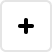
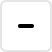
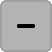
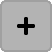
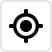
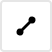
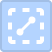
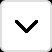
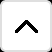
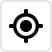
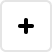
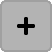
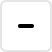
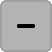
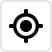
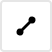
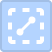
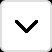
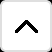
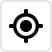

In [1]:
import numpy as np
import pandas as pd
from lets_plot import *
LetsPlot.setup_html()

In [2]:
np.random.seed(42)

In [3]:
plot = ggplot({'x': [0, 1.5, 1.7, 2], 'y': [0, 1, 1.8, 4]}, aes('x', 'y')) + geom_point() 

### Default usage
`smooth_labels()` without any parameters or method calls displays the coefficient of determination (R²).

In [4]:
plot + geom_smooth(deg=2, labels = smooth_labels())

### Multiline, size and text style

In [5]:
plot + geom_smooth(deg=2, labels = smooth_labels()
                   .line('\(R\^2=\)@..r2..')
                   .line('~eq')
                   .size(15)) + \
    theme(label_text=element_text(
         family='DejaVu Sans',
         face='italic',
         color='black'
     ))


In [6]:
t = [0.0, 1.5, 1.7, 2.0, 0, 0.5, 0.7, 2]
y = [0.0, 1.0, 1.8, 4.0, 2, 5.5, 6.0, 4.5]
g = ['a', 'a', 'a', 'a', 'b', 'b', 'b', 'b']

plot_groups = ggplot({'t': t, 'y': y, 'g': g}, aes(x ='t', y='y')) + geom_point() 

### Grouping, eq() function and positioning

In [7]:
plot_groups + geom_smooth(aes(x='t', y='y', color='g'), deg=2, labels = smooth_labels()
                .line('\(R\^2=\)@..r2.., \(R_{{adj}}\^2=\)@..adjr2.., ~eq')
                .format('..r2..', '.4f')
                .format('..adjr2..', '.4f')
                .eq(lhs='y(t)', rhs='t', format='.3f', threshold=0.01)
                .label_y(['bottom', 'top'])
                .size(15))